In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
# Assuming the file is named 'clusters.csv' and has no header row

df = pd.read_csv('cluster_output/sdhash/test/cluster_results__threshold_10_20250314_231519.csv', 
                 names=['File_Path', 'SHA256','SDHash', 'Cluster_Label', 'Threshold'])

# # Count occurrences of each cluster label to get cluster sizes
# cluster_sizes = df['Cluster_Label'].value_counts()


In [30]:
df.head(9)

,File_Path,SHA256,SDHash,Cluster_Label,Threshold
0,File_Path,SHA256,SDHash,Cluster_Label,Threshold
1,/usr/src/app/datacopy/evasive-it/2021/68f22901...,68f22901ca321609823c5211354ef8946432d77be33150...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,0,10
2,/usr/src/app/datacopy/evasive-it/2021/a470823d...,a470823db33706bd6ea4768a5240e82815fac99ce26dbd...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,0,10
3,/usr/src/app/datacopy/evasive-it/2021/21fc6ae8...,21fc6ae8f7c0619af4c03ce300bb271f3d3ec43cd196bb...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,0,10
4,/usr/src/app/datacopy/evasive-it/2021/4149f025...,4149f025cfce38098d9b8a048c169651a38d312ed6e026...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,0,10
5,/usr/src/app/datacopy/evasive-it/2021/55a3c455...,55a3c455cfbd70fd91663e251ea65db6452edbb0d730c8...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,1,10
6,/usr/src/app/datacopy/evasive-it/2021/b9c705ce...,b9c705cedc02d6ef6ea1764f6dfb0724ce66c878f5c033...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,1,10
7,/usr/src/app/datacopy/evasive-it/2021/2b81bcbc...,2b81bcbc4e1b8e1c6f7ab1eca090887c0710a73e4fd417...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,2,10
8,/usr/src/app/datacopy/evasive-it/2021/ce46e8fd...,ce46e8fd19e006eb7dd8c14c64050025d8771fc092097f...,sdbf:03:102:/usr/src/app/datacopy/evasive-it/2...,0,10


In [31]:
# # Count occurrences of each cluster label to get cluster sizes
# cluster_sizes = df['Cluster_Label'].value_counts()

# # Filter out clusters with only 1 element
# cluster_sizes_filtered = cluster_sizes[cluster_sizes > 1]

# # Create a histogram with log scale
# plt.figure(figsize=(10, 6))
# plt.hist(cluster_sizes_filtered, 
#          bins=20,  # You can adjust the number of bins
#          log=True,  # Log scale on y-axis
#          color='blue',
#          alpha=0.7)

# # Customize the plot
# plt.xlabel('Cluster Size')
# plt.ylabel('Frequency (log scale)')
# plt.title('Histogram of Cluster Sizes (Excluding Singletons)')
# plt.grid(True, which="both", ls="-", alpha=0.2)

# # Add text with statistics
# plt.text(0.02, 0.98,
#          f'Total Clusters (>1): {len(cluster_sizes_filtered)}\n'
#          f'Total Files in Clusters: {cluster_sizes_filtered.sum()}\n'
#          f'Singletons Excluded: {len(cluster_sizes) - len(cluster_sizes_filtered)}',
#          transform=plt.gca().transAxes)

# # Adjust layout and display
# plt.tight_layout()
# plt.show()

# # Print statistics
# print(f"Number of clusters with more than 1 element: {len(cluster_sizes_filtered)}")
# print(f"Total files in non-singleton clusters: {cluster_sizes_filtered.sum()}")
# print(f"Number of singleton clusters excluded: {len(cluster_sizes) - len(cluster_sizes_filtered)}")
# print(f"Largest cluster size: {cluster_sizes_filtered.max()}")
# print(f"Smallest cluster size: {cluster_sizes_filtered.min()}")

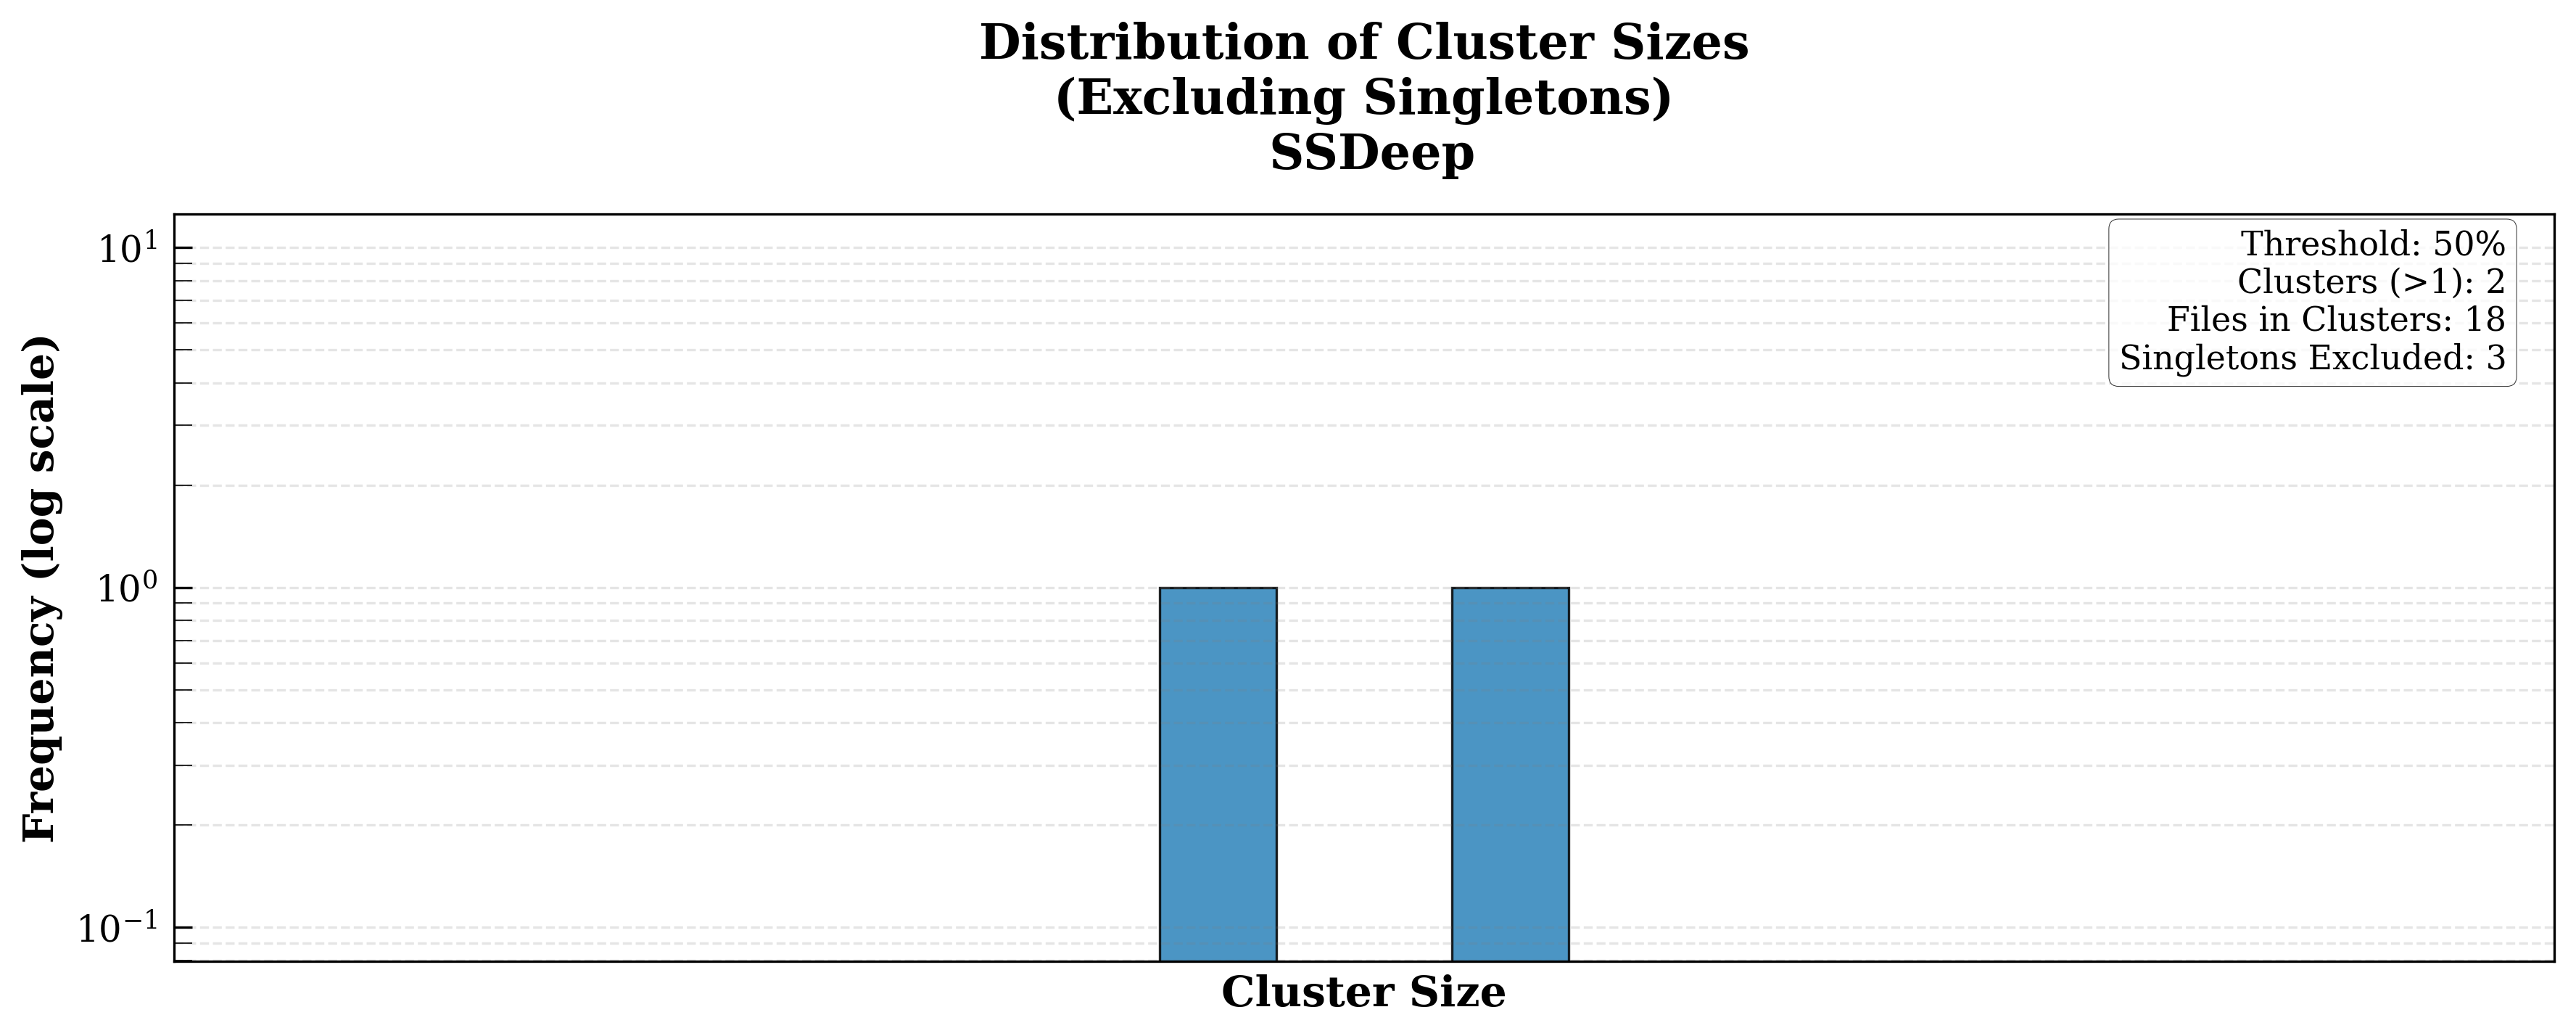

Clustering threshold: 50%
Number of clusters with more than 1 element: 2
Total files in non-singleton clusters: 18
Number of singleton clusters excluded: 3
Largest cluster size: 16
Smallest cluster size: 2
Unique cluster sizes present: 16, 2


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'font.family': 'serif',
    'figure.dpi': 300
})

# Get threshold from user
threshold = 50



# Count occurrences of each cluster label to get cluster sizes
cluster_sizes = df['Cluster_Label'].value_counts()

# Filter out clusters with only 1 element
cluster_sizes_filtered = cluster_sizes[cluster_sizes > 1]

# Get unique cluster sizes and their frequencies
unique_sizes, frequencies = zip(*cluster_sizes_filtered.value_counts().items())
unique_sizes = list(unique_sizes)
frequencies = list(frequencies)

# Create figure with increased width for large range
fig, ax = plt.subplots(figsize=(12, 6))  # Width 12in for 500-1400 range

# Create bar plot with adjusted width
bar_width = max(1, (max(unique_sizes) - min(unique_sizes)) / len(unique_sizes) * 0.8)  # Dynamic width
bars = ax.bar(unique_sizes, 
              frequencies,
              width=bar_width,
              color='#2b83ba',
              edgecolor='black',
              linewidth=0.8,
              alpha=0.85)

# Set log scale on y-axis
ax.set_yscale('log')

# Customize the plot
ax.set_xlabel('Cluster Size', weight='bold')
ax.set_ylabel('Frequency (log scale)', weight='bold')
ax.set_title('Distribution of Cluster Sizes\n(Excluding Singletons)\n SSDeep', 
             weight='bold', 
             pad=15)

# Improve x-axis labels: show ticks every 100 units within range
min_size = min(unique_sizes)
max_size = max(unique_sizes)
tick_positions = range(((min_size // 100) * 100), ((max_size // 100) + 1) * 100, 100)
ax.set_xticks([t for t in tick_positions if min_size <= t <= max_size])
ax.set_xticklabels([str(t) for t in ax.get_xticks()], rotation=45, ha='right')

# Set x-axis limits to focus on the data range
ax.set_xlim(min_size - 50, max_size + 50)

# Customize grid
ax.grid(True, which="both", ls="--", alpha=0.2, color='gray')

# Customize ticks
ax.tick_params(axis='both', which='both', direction='in', length=6)

# Add text box with statistics
stats_text = (f'Threshold: {threshold}%\n'
              f'Clusters (>1): {len(cluster_sizes_filtered):,}\n'
              f'Files in Clusters: {cluster_sizes_filtered.sum():,}\n'
              f'Singletons Excluded: {len(cluster_sizes) - len(cluster_sizes_filtered):,}')

ax.text(0.98, 0.98, stats_text,
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=11)

# Adjust layout with extra bottom space
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

# Save the plot (optional)
# plt.savefig('cluster_distribution.pdf', format='pdf', bbox_inches='tight', dpi=300)
# plt.savefig('cluster_distribution.png', format='png', bbox_inches='tight', dpi=300)

# Display the plot
plt.show()

# Print statistics
print(f"Clustering threshold: {threshold}%")
print(f"Number of clusters with more than 1 element: {len(cluster_sizes_filtered):,}")
print(f"Total files in non-singleton clusters: {cluster_sizes_filtered.sum():,}")
print(f"Number of singleton clusters excluded: {len(cluster_sizes) - len(cluster_sizes_filtered):,}")
print(f"Largest cluster size: {cluster_sizes_filtered.max():,}")
print(f"Smallest cluster size: {cluster_sizes_filtered.min():,}")
print(f"Unique cluster sizes present: {', '.join(map(str, unique_sizes))}")